In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#  Read the datasets
sensor1 = pd.read_csv("sensor 1.csv")
sensor2 = pd.read_csv("sensor 2.csv")

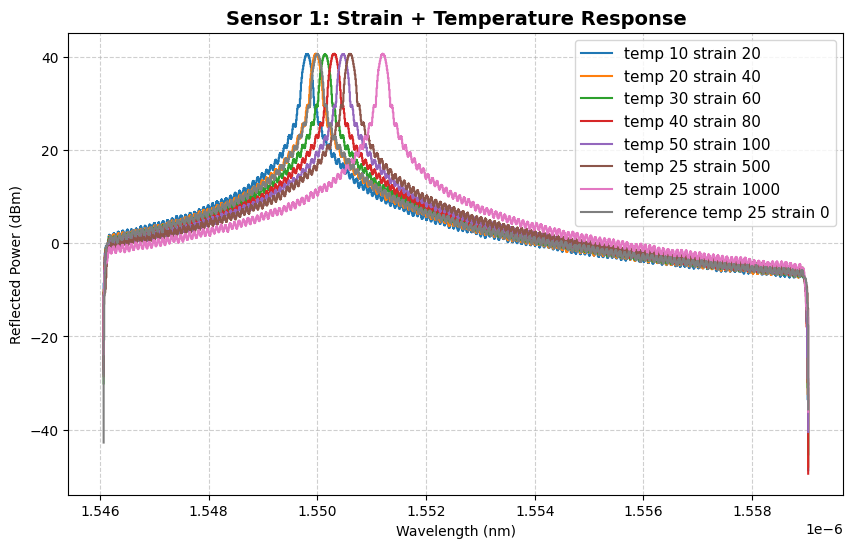

In [3]:
# Plotting Sensor 1 
plt.figure(figsize=(10, 6))
for col in sensor1.columns[1:]:
    plt.plot(sensor1["wavelength"], sensor1[col], label=col)
plt.title("Sensor 1: Strain + Temperature Response", fontsize=14, fontweight='bold')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflected Power (dBm)")
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

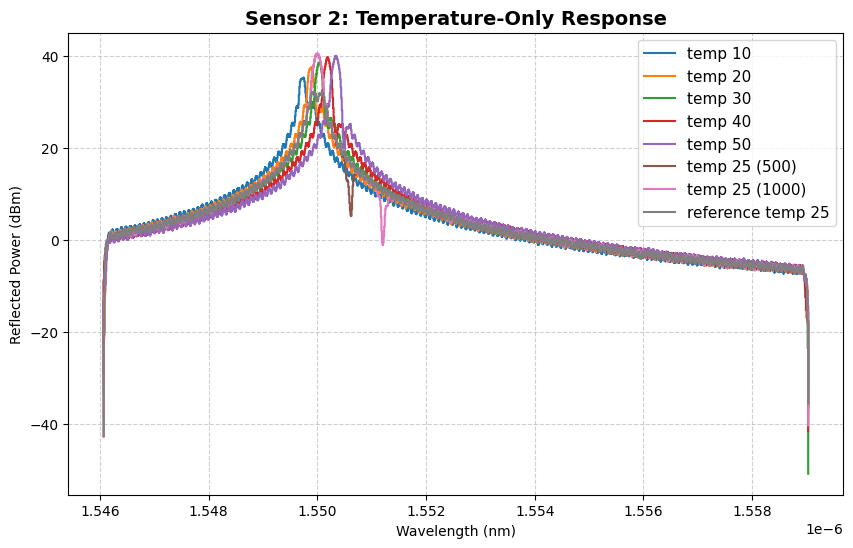

In [4]:
#plotting sensor 2
plt.figure(figsize=(10, 6))
for col in sensor2.columns[1:]:
    plt.plot(sensor2["wavelength"], sensor2[col], label=col)

plt.title("Sensor 2: Temperature-Only Response", fontsize=14, fontweight='bold')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflected Power (dBm)")
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Converted wavelength from meters -> nm (mean before conversion: 1.553e-06)
Converted wavelength from meters -> nm (mean before conversion: 1.553e-06)
Reference peak (Sensor1): 1549.990000 nm
Reference peak (Sensor2): 1550.090000 nm
Saved peaks_sensor1.csv and peaks_sensor2.csv

Sensor 1 Peaks :
                 Condition  Peak_Wavelength_nm  Peak_Power  Delta_nm_from_ref  Delta_pm_from_ref  Peak_Index
         temp 10 strain 20             1549.82   40.574230              -0.17             -170.0      117109
         temp 20 strain 40             1549.97   40.611285              -0.02              -20.0      115192
         temp 30 strain 60             1550.14   40.485548               0.15              150.0      113020
         temp 40 strain 80             1550.31   40.602729               0.32              320.0      110786
        temp 50 strain 100             1550.48   40.535280               0.49              490.0      108642
        temp 25 strain 500             1550.60   4

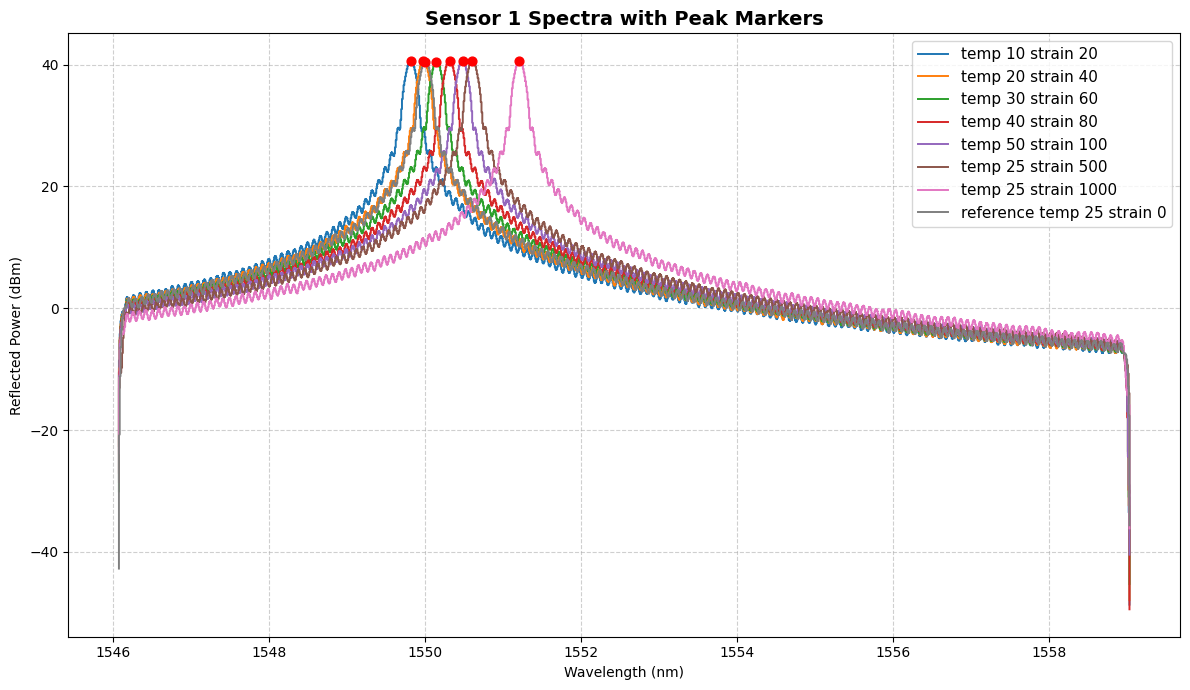

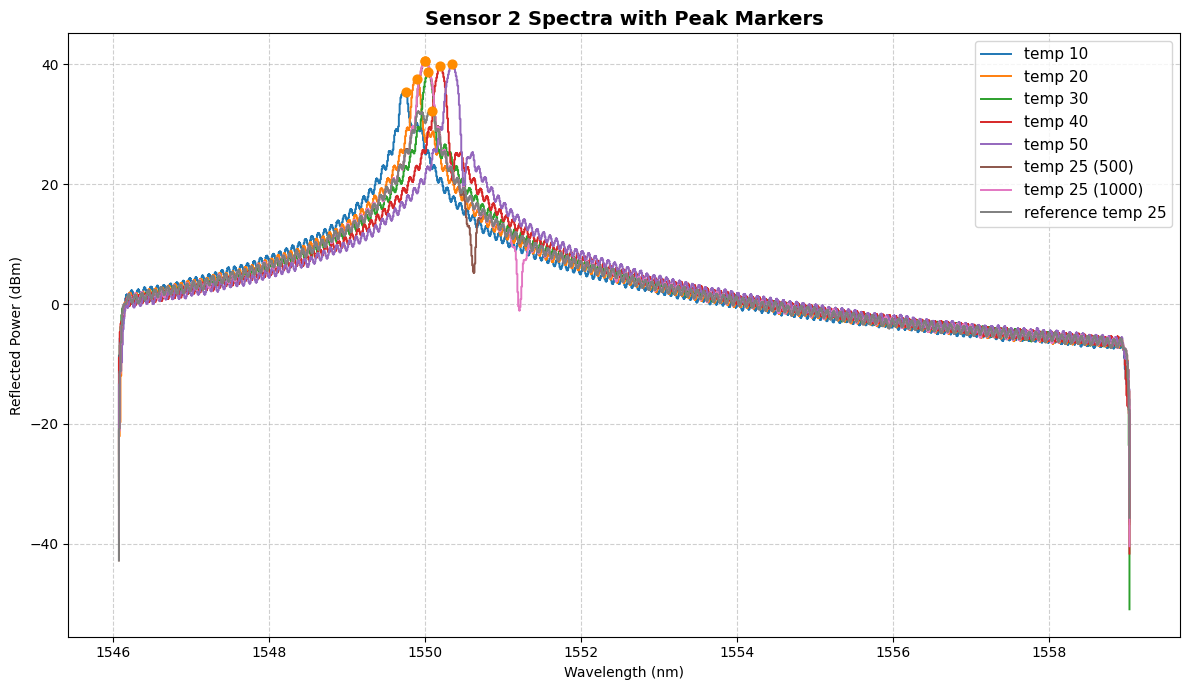

In [5]:
SENSOR1_FILE = "sensor 1.csv"
SENSOR2_FILE = "sensor 2.csv"
s1 = pd.read_csv(SENSOR1_FILE)
s2 = pd.read_csv(SENSOR2_FILE)
def ensure_wavelength_nm(df, colname="wavelength"):
    # If mean value < 100, assume values are in meters -> convert to nm
    mean_wl = df[colname].dropna().astype(float).mean()
    if mean_wl < 100:  
        df[colname] = df[colname].astype(float) * 1e9
        print(f"Converted wavelength from meters -> nm (mean before conversion: {mean_wl:.3e})")
    else:
        print(f"Wavelength is already nm (mean: {mean_wl:.2f} nm)")
    return df

s1 = ensure_wavelength_nm(s1)
s2 = ensure_wavelength_nm(s2)
def extract_peaks(df):
    peaks = []
    wl = df["wavelength"].values
    for col in df.drop(columns=["wavelength"]).columns:
        sig = df[col].values
        # idxmax handles the maximum
        idx = int(np.nanargmax(sig))
        peaks.append({
            "Condition": col,
            "Peak_Wavelength_nm": float(wl[idx]),
            "Peak_Power": float(sig[idx]),
            "Peak_Index": idx
        })
    peaks_df = pd.DataFrame(peaks)
    return peaks_df

peaks_s1 = extract_peaks(s1)
peaks_s2 = extract_peaks(s2)
# reference peaks (by 'reference')
def find_reference_peak(peaks_df, ref_keyword="reference"):
    matches = peaks_df[peaks_df["Condition"].str.contains(ref_keyword, case=False, na=False)]
    if not matches.empty:
        return matches.iloc[0]["Peak_Wavelength_nm"]
    else:
        # fallback: choose last as fallback
        print("Warning: reference condition not found by keyword. Using last condition as reference.")
        return peaks_df.iloc[-1]["Peak_Wavelength_nm"]

ref_wl_s1 = find_reference_peak(peaks_s1, ref_keyword="reference")
ref_wl_s2 = find_reference_peak(peaks_s2, ref_keyword="reference")
print(f"Reference peak (Sensor1): {ref_wl_s1:.6f} nm")
print(f"Reference peak (Sensor2): {ref_wl_s2:.6f} nm")
# Compute delta lambda (nm and pm) relative to reference
peaks_s1["Delta_nm_from_ref"] = peaks_s1["Peak_Wavelength_nm"] - ref_wl_s1
peaks_s1["Delta_pm_from_ref"] = peaks_s1["Delta_nm_from_ref"] * 1000.0
peaks_s2["Delta_nm_from_ref"] = peaks_s2["Peak_Wavelength_nm"] - ref_wl_s2
peaks_s2["Delta_pm_from_ref"] = peaks_s2["Delta_nm_from_ref"] * 1000.0
# Reorder columns
cols_order = ["Condition", "Peak_Wavelength_nm", "Peak_Power", "Delta_nm_from_ref", "Delta_pm_from_ref", "Peak_Index"]
peaks_s1 = peaks_s1[cols_order]
peaks_s2 = peaks_s2[cols_order]
peaks_s1.to_csv("peaks_sensor 1.csv", index=False)
peaks_s2.to_csv("peaks_sensor 2.csv", index=False)
print("Saved peaks_sensor1.csv and peaks_sensor2.csv")
# Print the tables
print("\nSensor 1 Peaks :")
print(peaks_s1.to_string(index=False))
print("\nSensor 2 Peaks :")
print(peaks_s2.to_string(index=False))
plt.figure(figsize=(12, 7))
for _, row in peaks_s1.iterrows():
    cond = row["Condition"]
    plt.plot(s1["wavelength"], s1[cond], label=cond, linewidth=1.4)
    plt.scatter(row["Peak_Wavelength_nm"], row["Peak_Power"], color="red", zorder=6, s=40)

plt.title("Sensor 1 Spectra with Peak Markers", fontsize=14, fontweight='bold')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflected Power (dBm)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 7))
for _, row in peaks_s2.iterrows():
    cond = row["Condition"]
    plt.plot(s2["wavelength"], s2[cond], label=cond, linewidth=1.4)
    plt.scatter(row["Peak_Wavelength_nm"], row["Peak_Power"], color="darkorange", zorder=6, s=40)

plt.title("Sensor 2 Spectra with Peak Markers", fontsize=14, fontweight='bold')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflected Power (dBm)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

In [6]:
s1 = pd.read_csv("sensor 1.csv")
s2 = pd.read_csv("sensor 2.csv")

print("\n--- Sensor 1 Columns ---")
print(s1.columns.tolist())

print("\n--- Sensor 2 Columns ---")
print(s2.columns.tolist())


--- Sensor 1 Columns ---
['wavelength', 'temp 10 strain 20', 'temp 20 strain 40', 'temp 30 strain 60', 'temp 40 strain 80', 'temp 50 strain 100', 'temp 25 strain 500', 'temp 25 strain 1000', 'reference temp 25 strain 0']

--- Sensor 2 Columns ---
['wavelength', 'temp 10', 'temp 20', 'temp 30', 'temp 40', 'temp 50', 'temp 25 (500)', 'temp 25 (1000)', 'reference temp 25']


Converted wavelength from meters to nm.
Converted wavelength from meters to nm.


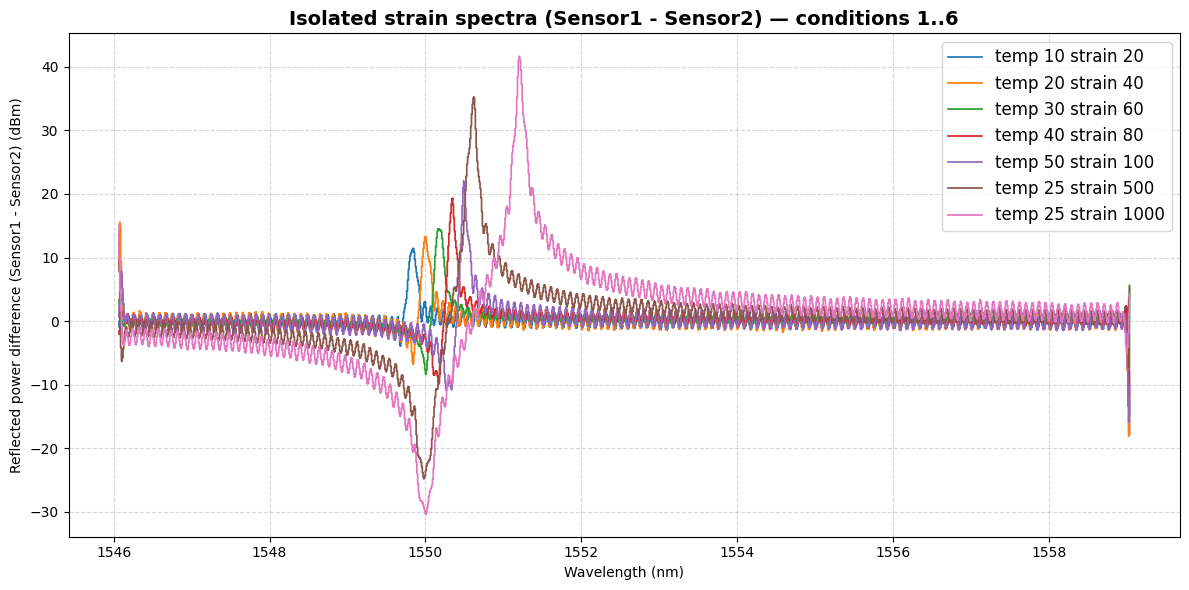

In [7]:
import numpy as np
# config
S1_FILE = "sensor 1.csv"
S2_FILE = "sensor 2.csv"
s1 = pd.read_csv(S1_FILE)
s2 = pd.read_csv(S2_FILE)
# wavelength in nm
def ensure_nm(df):
    m = df['wavelength'].astype(float).mean()
    if m < 100:   
        df['wavelength'] = df['wavelength'].astype(float) * 1e9
        print("Converted wavelength from meters to nm.")
    return df
s1 = ensure_nm(s1)
s2 = ensure_nm(s2)
cols_s1 = list(s1.columns[1:8])   
cols_s2 = list(s2.columns[1:8])   
# difference (strain spectrum) 
strain_spectra = pd.DataFrame({'wavelength': s1['wavelength']})
for c1, c2 in zip(cols_s1, cols_s2):
    strain_spectra[c1] = s1[c1].values - s2[c2].values
strain_spectra.to_csv("strain_spectra.csv", index=False)
# Plot: each condition's strain spectrum
plt.figure(figsize=(12,6))
for col in strain_spectra.columns[1:]:
    plt.plot(strain_spectra['wavelength'], strain_spectra[col], linewidth=1.25, label=col)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflected power difference (Sensor1 - Sensor2) (dBm)")
plt.title("Isolated strain spectra (Sensor1 - Sensor2) — conditions 1..6", fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Filtered data shape: (140232, 8)
Wavelength range after truncation: 1547.0 - 1558.0 nm


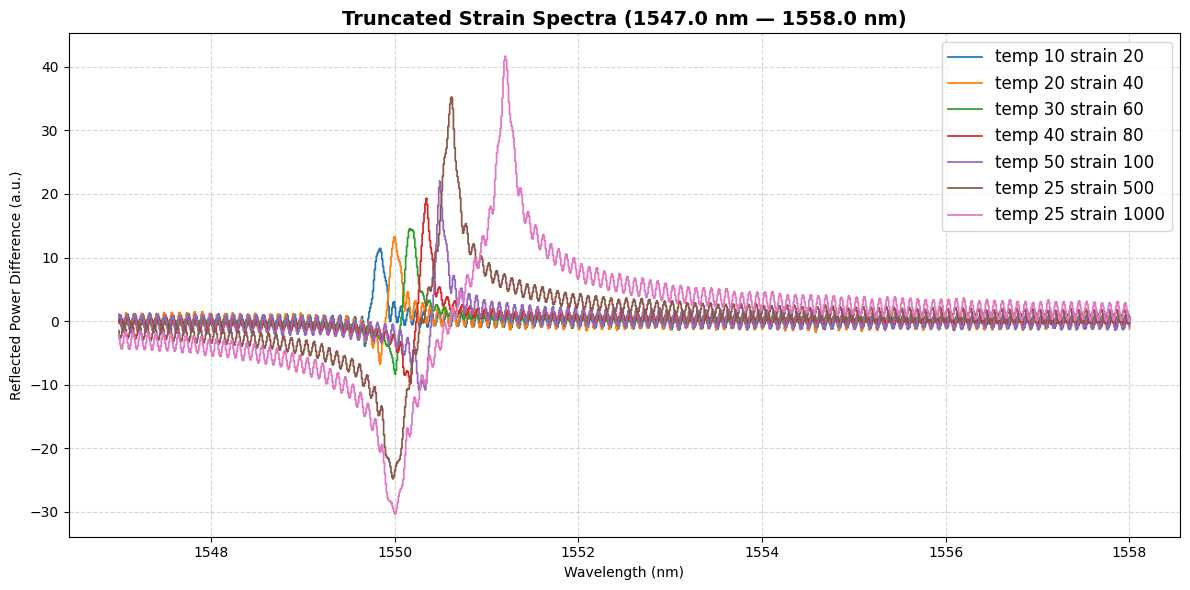


Extracted Peak Table (Filtered Range):

   Strain (µε)  Peak Power (a.u.)  Peak Wavelength (nm)
0           20          11.445373               1549.84
1           40          13.275391               1550.00
2           60          14.515627               1550.17
3           80          19.282866               1550.35
4          100          21.999986               1550.49
5          500          35.232621               1550.62
6         1000          41.666808               1551.21


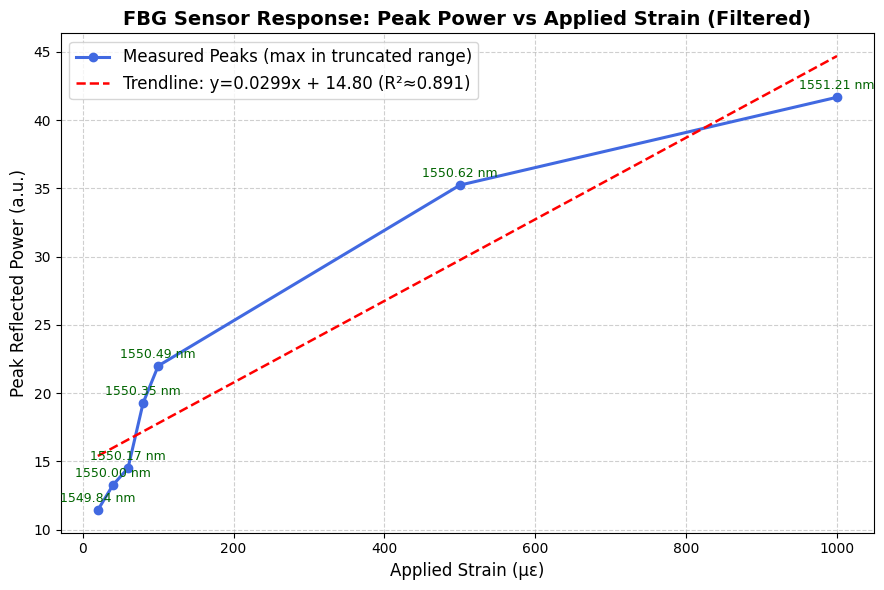

In [8]:
strain_spectra = pd.read_csv("strain_spectra.csv")
# Filter wavelength range (truncated data)
wl_min, wl_max = 1547.0, 1558.0
filtered = strain_spectra[
    (strain_spectra['wavelength'] >= wl_min) &
    (strain_spectra['wavelength'] <= wl_max)
].reset_index(drop=True)
print(f"Filtered data shape: {filtered.shape}")
print(f"Wavelength range after truncation: {filtered['wavelength'].min()} - {filtered['wavelength'].max()} nm")
microstrain = [20, 40, 60, 80, 100, 500, 1000]
# Identify condition columns exclude 'wavelength' and any reference)
cond_columns = [c for c in filtered.columns[1:] if "reference" not in c.lower()]
# If there are more columns than microstrain entries, trim to microstrain length
cond_columns = cond_columns[:len(microstrain)]
# Plot 1: Truncated spectra 
plt.figure(figsize=(12, 6))
for col in cond_columns:
    plt.plot(filtered['wavelength'], filtered[col], linewidth=1.25, label=col)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflected Power Difference (a.u.)")
plt.title(f"Truncated Strain Spectra ({wl_min:.1f} nm — {wl_max:.1f} nm)", fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Extract peaks from truncated spectra 
peak_powers = []
peak_wavelengths = []
for col in cond_columns:
    # index of maximum within the truncated region
    idx_max = filtered[col].idxmax()
    peak_power = filtered[col].iloc[idx_max]
    peak_wl = filtered['wavelength'].iloc[idx_max]
    peak_powers.append(peak_power)
    peak_wavelengths.append(peak_wl)
# Build peak table and sort by strain
peak_table = pd.DataFrame({
    "Strain (µε)": microstrain,
    "Peak Power (a.u.)": peak_powers,
    "Peak Wavelength (nm)": peak_wavelengths
}).sort_values("Strain (µε)").reset_index(drop=True)

print("\nExtracted Peak Table (Filtered Range):\n")
print(peak_table)
# Plot 2: Peak Power vs Strain (curve) with wavelength labels & trendline
plt.figure(figsize=(9, 6))
plt.plot(peak_table["Strain (µε)"], peak_table["Peak Power (a.u.)"],
         color='royalblue', linewidth=2.2, marker='o', label='Measured Peaks (max in truncated range)')
# Label each point with its wavelength
for i, (s, p, wl) in enumerate(zip(peak_table["Strain (µε)"], peak_table["Peak Power (a.u.)"], peak_table["Peak Wavelength (nm)"])):
    plt.text(s, p + 0.6, f"{wl:.2f} nm", ha='center', fontsize=9, color='darkgreen')
# Linear trendline
z = np.polyfit(peak_table["Strain (µε)"], peak_table["Peak Power (a.u.)"], 1)
p = np.poly1d(z)
plt.plot(peak_table["Strain (µε)"], p(peak_table["Strain (µε)"]), "r--", linewidth=1.8,
         label=f"Trendline: y={z[0]:.4f}x + {z[1]:.2f} (R²≈{np.corrcoef(peak_table['Strain (µε)'], peak_table['Peak Power (a.u.)'])[0,1]**2:.3f})")
plt.title("FBG Sensor Response: Peak Power vs Applied Strain (Filtered)", fontsize=14, fontweight='bold')
plt.xlabel("Applied Strain (µε)", fontsize=12)
plt.ylabel("Peak Reflected Power (a.u.)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
filtered.to_csv("strain_spectra_trunc.csv", index=False)

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
strain_spectra = pd.read_csv("strain_spectra_trunc.csv")
# Conditions (columns to use as samples)
conditions = list(strain_spectra.columns[1:])  # skip 'wavelength'
# Reshape: each condition is a row (sample), each wavelength is a feature
X = []
y = []

for cond in conditions:
    spectrum = strain_spectra[cond].values   # spectral vector
    X.append(spectrum)
    # extract strain value from the column name
    if "1000" in cond:
        y.append(1000)
    elif "500" in cond:
        y.append(500)
    else:
        # pick the last number as strain
        y.append(int(cond.split()[-1]))
        
X = np.array(X)
y = np.array(y)
print("Feature matrix shape:", X.shape)  # (n_samples, n_wavelengths)
print("Labels:", y)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Pipeline: PCA + Linear Regression
model = Pipeline([
    ("pca", PCA(n_components=3)),   # reduce to 5 principal components
    ("reg", LinearRegression())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# Evaluate
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
# Compare actual vs predicted
results = pd.DataFrame({"Actual": y_test, "Predicted": np.round(y_pred, 2)})
print(results)


Feature matrix shape: (7, 140232)
Labels: [  20   40   60   80  100  500 1000]
MSE: 1776.065469635247
R^2: 0.963868469198198
   Actual  Predicted
0      20       3.72
1      40      12.69
2     500     434.30


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

In [11]:
strain_spectra = pd.read_csv("strain_spectra_trunc.csv")
# Extract feature matrix (X) and strain labels (y)
conditions = list(strain_spectra.columns[1:])  # skip wavelength column
X, y = [], []
for cond in conditions:
    spectrum = strain_spectra[cond].values
    X.append(spectrum)
    
    # Assign strain values or condition labels
    if "1000" in cond:
        y.append(2)   # Fault
    elif "500" in cond:
        y.append(1)   # Warning
    else:
        y.append(0)   # Normal

X = np.array(X)
y = np.array(y)
print("Feature matrix shape:", X.shape)
print("Labels distribution:", np.unique(y, return_counts=True))

Feature matrix shape: (7, 140232)
Labels distribution: (array([0, 1, 2]), array([5, 1, 1]))


In [12]:
# Split classes
X_normal, X_warning, X_fault = X[y==0], X[y==1], X[y==2]
# Upsample minority classes
X_warning_up, y_warning_up = resample(X_warning, y[y==1], replace=True, n_samples=len(X_normal), random_state=42)
X_fault_up, y_fault_up = resample(X_fault, y[y==2], replace=True, n_samples=len(X_normal), random_state=42)
# Combine balanced dataset
X_balanced = np.vstack([X_normal, X_warning_up, X_fault_up])
y_balanced = np.concatenate([y[y==0], y_warning_up, y_fault_up])
print("Balanced label distribution:", np.unique(y_balanced, return_counts=True))
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)

Balanced label distribution: (array([0, 1, 2]), array([5, 5, 5]))


Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         1
     Warning       1.00      1.00      1.00         2
       Fault       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Confusion Matrix:
 [[1 0 0]
 [0 2 0]
 [0 0 2]]


<Figure size 600x500 with 0 Axes>

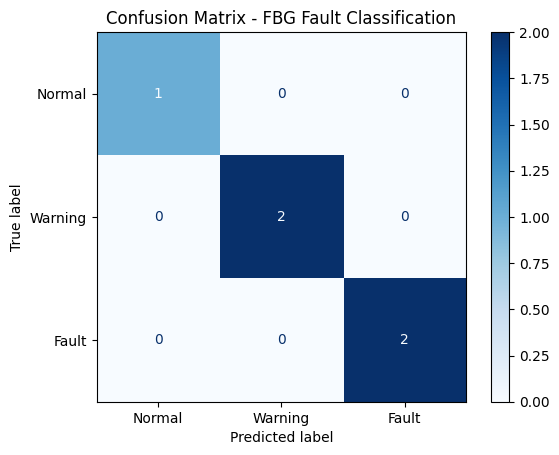

In [13]:
# pipeline: PCA → RandomForest
clf = Pipeline([
    ("pca", PCA(n_components=3)),  
    ("rf", RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=["Normal", "Warning", "Fault"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Warning", "Fault"]
)

disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix - FBG Fault Classification")
plt.grid(False)
plt.show()

In [14]:
def early_warning_system(pred_prob, thresholds={'Normal':0.6, 'Warning':0.7, 'Fault':0.8}):
    classes = ['Normal', 'Warning', 'Fault']
    predicted_class = classes[np.argmax(pred_prob)]
    confidence = np.max(pred_prob)
    
    if predicted_class == "Fault" and confidence > thresholds['Fault']:
        alert = " FAULT DETECTED – Immediate shutdown required."
    elif predicted_class == "Warning" and confidence > thresholds['Warning']:
        alert = " WARNING – System instability detected."
    else:
        alert = " NORMAL OPERATION."
        
    return predicted_class, confidence, alert

# early warning logic to test data
pred_probs = clf.predict_proba(X_test)
for i, prob in enumerate(pred_probs[:5]):  # show first 5 samples
    label, conf, alert = early_warning_system(prob)
    print(f"Sample {i+1}: Predicted={label} | Confidence={conf:.2f} | {alert}")

Sample 1: Predicted=Warning | Confidence=0.98 |  WARNING – System instability detected.
Sample 2: Predicted=Fault | Confidence=0.98 |  FAULT DETECTED – Immediate shutdown required.
Sample 3: Predicted=Normal | Confidence=0.86 |  NORMAL OPERATION.
Sample 4: Predicted=Fault | Confidence=0.98 |  FAULT DETECTED – Immediate shutdown required.
Sample 5: Predicted=Warning | Confidence=0.98 |  WARNING – System instability detected.


In [15]:
# trained model for real-time use
joblib.dump(clf, "FBG_Fault_Detector.pkl")

print(" Model saved as 'FBG_Fault_Detector.pkl' for deployment.")
# Trial
# simulate real-time prediction
def simulate_realtime(sensor_data):
    pred_prob = clf.predict_proba(sensor_data.reshape(1, -1))[0]
    label, conf, alert = early_warning_system(pred_prob)
    return f"Predicted: {label} | Confidence: {conf:.2f} | {alert}"

# usage (use one of your spectra samples)
print(simulate_realtime(X_test[0]))

 Model saved as 'FBG_Fault_Detector.pkl' for deployment.
Predicted: Warning | Confidence: 0.98 |  WARNING – System instability detected.
